# 06b SNR Decorrelation Correction

**Author:** Florian Klaver

Post-hoc correction of existing coherence rasters using approach from Tamm et al. (2016).

**Pipeline:**
```
coh_before/after.tif  +  GRD σ⁰ (nearest date)  →  γ_SNR_pair (per pixel)
γ_temporal = γ_measured / γ_SNR_pair  →  coh_before/after_snrcorr.tif
```

In [1]:
import os, glob, sys, warnings
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import geopandas as gpd
from rasterio.mask import mask as rio_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

%matplotlib inline

# Paths
BASE = "c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection"
SRC_DIR = f"{BASE}/src"
COH_DIR = f"{BASE}/data/features_coherence"
COH_CORR_DIR = f"{BASE}/data/features_coherence_snrcorr"
GRD_DIR = f"{BASE}/data/Sentinel_S1"
MASKS_DIR = f"{BASE}/data/ground_truth_masks"
AV_GPKG = f"{BASE}/data/amtliche_vermessung_zh/DM01AVZH24LV95.gpkg"
SLC_IDX_CSV = f"{BASE}/data/slc_scene_index.csv"
TM_CSV = f"{BASE}/data/temporal_matches.csv"
DIAG_OUT_DIR = f"{BASE}/data/operational_results/diagnostics/snrcorr"
IMG_OUT_DIR = f"{BASE}/docs/images/snr_correction"


os.makedirs(COH_CORR_DIR, exist_ok=True)
os.makedirs(DIAG_OUT_DIR, exist_ok=True)
os.makedirs(IMG_OUT_DIR, exist_ok=True)

# Add src to path so we can import snr_correction
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from snr_correction import (
    linear_from_db, db_from_linear,
    compute_gamma_snr_pair, apply_snr_correction,
    NESZ_VV_DB, NESZ_VH_DB, GAMMA_SNR_FLOOR,
)

print(f"NESZ_VV = {NESZ_VV_DB} dB  ({linear_from_db(NESZ_VV_DB):.5f} linear)")
print(f"NESZ_VH = {NESZ_VH_DB} dB  ({linear_from_db(NESZ_VH_DB):.5f} linear)")
print(f"gamma_snr floor = {GAMMA_SNR_FLOOR}  (max correction factor = {1/GAMMA_SNR_FLOOR:.1f}x)")
print(f"Output dir: {COH_CORR_DIR}")

NESZ_VV = -25.0 dB  (0.00316 linear)
NESZ_VH = -27.0 dB  (0.00200 linear)
gamma_snr floor = 0.1  (max correction factor = 10.0x)
Output dir: c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/data/features_coherence_snrcorr


## 1. GRD raster date index

In [2]:
GRD_TOLERANCE_DAYS = 3

# Build an index of available GRD files by date for quick lookup
grd_files = sorted(glob.glob(f"{GRD_DIR}/S1_*.tif"))
grd_index = {}   # key: datetime.date, value: path
for f in grd_files:
    stem = os.path.basename(f).replace('.tif', '').replace('S1_', '')
    try:
        dt = datetime.strptime(stem, '%Y%m%d').date()
        grd_index[dt] = f
    except ValueError:
        pass

print(f"GRD files indexed: {len(grd_index)}")
print(f"Date range: {min(grd_index)} to {max(grd_index)}")

# Helper to find nearest GRD file by date within tolerance
def find_nearest_grd(slc_date_str: str, tolerance_days: int = GRD_TOLERANCE_DAYS):
    """Return (path, delta_days) for the closest GRD within tolerance, else (None, None)."""
    target = datetime.strptime(slc_date_str, '%Y-%m-%d').date()
    best_path, best_delta = None, 9999
    for grd_dt, grd_path in grd_index.items():
        delta = abs((grd_dt - target).days)
        if delta < best_delta:
            best_delta = delta
            best_path = grd_path
    if best_delta <= tolerance_days:
        return best_path, best_delta
    return None, None


GRD files indexed: 109
Date range: 2019-04-30 to 2023-10-07


## 2. Coherence inventory and SLC date lookup

In [3]:
# Load SLC index and build lookup for match_id -> SLC dates
slc_idx = pd.read_csv(SLC_IDX_CSV)
slc_idx['match_id'] = slc_idx['match_id'].astype(int)

before_tifs = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_DIR}/*_coh_before.tif")}
after_tifs = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_DIR}/*_coh_after.tif")}
valid_ids = sorted(set(before_tifs) & set(after_tifs))

print(f"Events with both coh_before + coh_after: {len(valid_ids)}")

# Build lookup: match_id -> (t1_date, t2_date, t3_date, t4_date)  [C1 + L1]
date_lut = slc_idx.set_index('match_id')[
    ['slc_t1_date', 'slc_t2_date', 'slc_t3_date', 'slc_t4_date']
].to_dict('index')

# Pre-check GRD availability for all SLC dates used
print("\nGRD availability per SLC date:")
all_slc_dates = set()
for mid in valid_ids:
    if mid not in date_lut:
        continue
    r = date_lut[mid]
    for col in ['slc_t1_date', 'slc_t2_date', 'slc_t3_date', 'slc_t4_date']:  # [L2]
        if pd.notna(r[col]):
            all_slc_dates.add(r[col])

# Check each SLC date against GRD index and report missing ones
miss_dates = []
for d in sorted(all_slc_dates):
    p, delta = find_nearest_grd(d)
    if p is None:
        miss_dates.append(d)
        print(f"  MISS: {d}")
    elif delta > 0:
        print(f"  {d}  ->  {os.path.basename(p)}  (delta={delta}d)")

print(f"\nTotal SLC dates: {len(all_slc_dates)}  "
      f"Matched: {len(all_slc_dates)-len(miss_dates)}  Missing: {len(miss_dates)}")

Events with both coh_before + coh_after: 36

GRD availability per SLC date:
  2019-05-01  ->  S1_20190430.tif  (delta=1d)
  2019-05-13  ->  S1_20190512.tif  (delta=1d)
  2020-05-25  ->  S1_20200524.tif  (delta=1d)
  2020-05-31  ->  S1_20200530.tif  (delta=1d)
  2020-06-06  ->  S1_20200605.tif  (delta=1d)
  2020-09-04  ->  S1_20200903.tif  (delta=1d)
  2020-09-22  ->  S1_20200921.tif  (delta=1d)
  2021-05-20  ->  S1_20210519.tif  (delta=1d)
  2021-06-01  ->  S1_20210531.tif  (delta=1d)
  2021-06-19  ->  S1_20210618.tif  (delta=1d)
  2021-07-25  ->  S1_20210724.tif  (delta=1d)
  2021-07-31  ->  S1_20210730.tif  (delta=1d)
  2021-08-18  ->  S1_20210817.tif  (delta=1d)
  2021-08-30  ->  S1_20210829.tif  (delta=1d)

Total SLC dates: 51  Matched: 51  Missing: 0


In [4]:
# Helper functions for loading and resampling GRD data to coherence grid
def get_coh_bands(src):
    """Return 0-based (vv_idx, vh_idx) by scanning for bands with values in [0,1]."""
    coh = []
    for b in range(1, src.count + 1):
        win = rasterio.windows.Window(0, 0, min(200, src.width), min(200, src.height))
        arr = src.read(b, window=win).astype(float)
        valid = arr[(arr > 0.001) & np.isfinite(arr)]
        if valid.size > 50 and valid.max() <= 1.0:
            coh.append(b - 1)
    return (coh[0] if len(coh) > 0 else None,
            coh[1] if len(coh) > 1 else None)


# Load GRD TIF 
def load_grd_linear(grd_path, nodata_floor_db=-35.0):
    """
    Load GRD TIF (Band1=VV dB, Band2=VH dB) and return (vv_lin, vh_lin, profile).
    Values below nodata_floor_db are set to NaN before converting to linear.
    """
    with rasterio.open(grd_path) as src:
        vv_db = src.read(1).astype(np.float32)
        vh_db = src.read(2).astype(np.float32)
        profile = src.profile.copy()
        nd = src.nodata
    if nd is not None:
        vv_db[vv_db == nd] = np.nan
        vh_db[vh_db == nd] = np.nan
    vv_db[vv_db < nodata_floor_db] = np.nan
    vh_db[vh_db < nodata_floor_db] = np.nan
    return linear_from_db(vv_db).astype(np.float32), linear_from_db(vh_db).astype(np.float32), profile


# Resample GRD array to coherence grid
def resample_to_coh_grid(src_arr, src_profile, coh_profile):
    """Bilinear-resample src_arr from GRD grid to coherence raster grid."""
    dst = np.full(
        (coh_profile['height'], coh_profile['width']),
        np.nan, dtype=np.float32
    )
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_profile['transform'],
        src_crs=src_profile['crs'],
        dst_transform=coh_profile['transform'],
        dst_crs=coh_profile['crs'],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst


print("Helper functions defined.")

Helper functions defined.


## 3. Per-event SNR correction

In [ ]:
NESZ_VV_LIN = float(linear_from_db(NESZ_VV_DB))
NESZ_VH_LIN = float(linear_from_db(NESZ_VH_DB))

event_reports = []   # per-event summary rows
n_skip = 0

# Process each event, apply SNR correction, and save results
for mid in valid_ids:
    if mid not in date_lut:
        print(f"  [SKIP] match_id={mid}: not in slc_scene_index")
        n_skip += 1
        continue

    r = date_lut[mid]
    t1, t2, t3, t4 = (r['slc_t1_date'], r['slc_t2_date'],   
                       r['slc_t3_date'], r['slc_t4_date'])

    # Find GRD for each SLC date
    grd_t1, d1 = find_nearest_grd(t1) if pd.notna(t1) else (None, None)
    grd_t2, d2 = find_nearest_grd(t2) if pd.notna(t2) else (None, None)
    grd_t3, d3 = find_nearest_grd(t3) if pd.notna(t3) else (None, None)
    grd_t4, d4 = find_nearest_grd(t4) if pd.notna(t4) else (None, None)  

    can_before = (grd_t1 is not None and grd_t2 is not None)
    can_after  = (grd_t3 is not None and grd_t4 is not None)  

    if not can_before and not can_after:
        print(f"  [SKIP] match_id={mid}: no GRD for any pair "
              f"(t1={t1}->{'MISS' if grd_t1 is None else f'd{d1}'}, "
              f"t2={t2}->{'MISS' if grd_t2 is None else f'd{d2}'}, "
              f"t3={t3}->{'MISS' if grd_t3 is None else f'd{d3}'}, "
              f"t4={t4}->{'MISS' if grd_t4 is None else f'd{d4}'})")  
        n_skip += 1
        continue

    # Load GRD data
    grd_cache = {}
    for date_str, grd_path in [('t1', grd_t1), ('t2', grd_t2),
                                ('t3', grd_t3), ('t4', grd_t4)]:  
        if grd_path is not None and grd_path not in grd_cache:
            grd_cache[grd_path] = load_grd_linear(grd_path)

    # Helper to get GRD data from cache
    def get_grd_linear(grd_path):
        if grd_path is None:
            return None, None, None
        return grd_cache[grd_path]

    # Initialise per-event report
    report = {'match_id': mid, 't1': t1, 't2': t2, 't3': t3, 't4': t4,  
              'grd_d1': d1, 'grd_d2': d2, 'grd_d3': d3, 'grd_d4': d4,   
              'before_ok': False, 'after_ok': False}

    # Process both pairs (before: t1-t2, after: t3-t4)  
    for pair_name, coh_path_key, ga_str, gb_str, grd_a, grd_b in [
        ('before', before_tifs[mid], 't1', 't2', grd_t1, grd_t2),
        ('after',  after_tifs[mid],  't3', 't4', grd_t3, grd_t4),  
    ]:
        can = (grd_a is not None and grd_b is not None)
        out_path = f"{COH_CORR_DIR}/{mid}_coh_{pair_name}_snrcorr.tif"

        if os.path.exists(out_path):
            report[f'{pair_name}_ok'] = True
            print(f"  [{mid}] {pair_name}: already on disk, skip")
            continue

        if not can:
            print(f"  [{mid}] {pair_name}: SKIPPED (GRD missing for {ga_str} or {gb_str})")
            continue

        vv_a, vh_a, prof_a = get_grd_linear(grd_a)
        vv_b, vh_b, prof_b = get_grd_linear(grd_b)

        # Check if GRD data is valid
        with rasterio.open(coh_path_key) as coh_src:
            coh_profile = coh_src.profile.copy()
            coh_profile.update(count=2, dtype='float32', nodata=np.nan,
                               compress='lzw')

            vv_idx, vh_idx = get_coh_bands(coh_src)
            if vv_idx is None:
                print(f"  [{mid}] {pair_name}: SKIPPED (no coherence band found)")
                continue

            coh_vv = coh_src.read(vv_idx + 1).astype(np.float32)
            coh_vh = coh_src.read(vh_idx + 1).astype(np.float32) if vh_idx is not None else np.full_like(coh_vv, np.nan)

            # Zero -> NaN (SNAP nodata at raster edges)
            coh_vv[coh_vv <= 0] = np.nan
            coh_vh[coh_vh <= 0] = np.nan

            # Resample both GRD acquisitions to this coherence grid
            vv_a_r = resample_to_coh_grid(vv_a, prof_a, coh_profile)
            vv_b_r = resample_to_coh_grid(vv_b, prof_b, coh_profile)
            vh_a_r = resample_to_coh_grid(vh_a, prof_a, coh_profile)
            vh_b_r = resample_to_coh_grid(vh_b, prof_b, coh_profile)

            # Compute γ_SNR_pair for VV and VH
            gsnr_vv = compute_gamma_snr_pair(vv_a_r, vv_b_r, NESZ_VV_LIN)
            gsnr_vh = compute_gamma_snr_pair(vh_a_r, vh_b_r, NESZ_VH_LIN)

            # Apply correction
            corr_vv = apply_snr_correction(coh_vv, gsnr_vv, floor=GAMMA_SNR_FLOOR)
            corr_vh = apply_snr_correction(coh_vh, gsnr_vh, floor=GAMMA_SNR_FLOOR)

            # Compute per-event stats (valid pixels only)
            def _stats(arr, name):
                v = arr[np.isfinite(arr) & (arr > 0.001)]
                return float(np.mean(v)) if v.size > 0 else np.nan

            mean_gsnr_vv = _stats(gsnr_vv, 'gsnr_vv')
            mean_gsnr_vh = _stats(gsnr_vh, 'gsnr_vh')
            mean_coh_before = _stats(coh_vv, 'coh_vv')
            mean_coh_after = _stats(corr_vv, 'corr_vv')

            report[f'{pair_name}_mean_gsnr_vv'] = mean_gsnr_vv
            report[f'{pair_name}_mean_gsnr_vh'] = mean_gsnr_vh
            report[f'{pair_name}_mean_cf_vv'] = (mean_coh_after / mean_coh_before
                                                    if mean_coh_before > 0 else np.nan)

            # Write corrected TIF (2-band: VV, VH)
            with rasterio.open(out_path, 'w', **coh_profile) as dst:
                dst.write(corr_vv, 1)
                dst.write(corr_vh, 2)
                dst.update_tags(1, name='coh_vv_snrcorr', nesz_db=NESZ_VV_DB)
                dst.update_tags(2, name='coh_vh_snrcorr', nesz_db=NESZ_VH_DB)

            report[f'{pair_name}_ok'] = True

    event_reports.append(report)

report_df = pd.DataFrame(event_reports)
n_before_ok = report_df['before_ok'].sum()
n_after_ok  = report_df['after_ok'].sum()
print(f"\n=== Summary ===")
print(f"Events processed:         {len(event_reports)}")
print(f"Events skipped:           {n_skip}")
print(f"coh_before corrected:     {n_before_ok}")
print(f"coh_after  corrected:     {n_after_ok}")
print(f"Both pairs corrected:     {(report_df['before_ok'] & report_df['after_ok']).sum()}")

  [0] before: already on disk, skip
  [0] after: already on disk, skip
  [1] before: already on disk, skip
  [1] after: already on disk, skip
  [2] before: already on disk, skip
  [2] after: already on disk, skip
  [3] before: already on disk, skip
  [3] after: already on disk, skip
  [4] before: already on disk, skip
  [4] after: already on disk, skip
  [5] before: already on disk, skip
  [5] after: already on disk, skip
  [6] before: already on disk, skip
  [6] after: already on disk, skip
  [7] before: already on disk, skip
  [7] after: already on disk, skip
  [8] before: already on disk, skip
  [8] after: already on disk, skip
  [10] before: already on disk, skip
  [10] after: already on disk, skip
  [11] before: already on disk, skip
  [11] after: already on disk, skip
  [12] before: already on disk, skip
  [12] after: already on disk, skip
  [21] before: already on disk, skip
  [21] after: already on disk, skip
  [39] before: already on disk, skip
  [39] after: already on disk, s

### Per-event SNR correction report

In [ ]:
# Display a summary table of results
disp_cols = ['match_id', 't1', 't2', 't3', 't4', 'grd_d1', 'grd_d2', 'grd_d3', 'grd_d4',  
             'before_ok', 'after_ok',
             'before_mean_gsnr_vv', 'before_mean_gsnr_vh',
             'after_mean_gsnr_vv',  'after_mean_gsnr_vh',
             'before_mean_cf_vv',   'after_mean_cf_vv']

disp = report_df[[c for c in disp_cols if c in report_df.columns]].copy()
float_cols = [c for c in disp.columns if 'mean' in c]
for c in float_cols:
    disp[c] = disp[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else 'N/A')

with pd.option_context('display.max_columns', None, 'display.width', 240):
    print(disp.to_string(index=False))

# Spot-check: are γ_SNR values physically plausible?
print("\nMean γ_SNR across all events:")
for col in ['before_mean_gsnr_vv', 'before_mean_gsnr_vh',
            'after_mean_gsnr_vv',  'after_mean_gsnr_vh']:
    if col in report_df.columns:
        vals = report_df[col].dropna()
        if vals.size > 0:
            print(f"  {col:<30s}: {vals.mean():.3f}  (range {vals.min():.3f}–{vals.max():.3f})")

 match_id         t1         t2         t3         t4  grd_d1  grd_d2  grd_d3  grd_d4  before_ok  after_ok
        0 2019-05-01 2019-05-07 2019-05-13 2019-05-19       1       0       1       0       True      True
        1 2019-05-07 2019-05-13 2019-05-19 2019-05-25       0       1       0       0       True      True
        2 2019-05-13 2019-05-19 2019-05-25 2019-05-31       1       0       0       0       True      True
        3 2019-05-19 2019-05-25 2019-05-31 2019-06-06       0       0       0       0       True      True
        4 2019-05-19 2019-05-25 2019-06-06 2019-06-12       0       0       0       0       True      True
        5 2019-05-25 2019-05-31 2019-06-06 2019-06-12       0       0       0       0       True      True
        6 2019-05-25 2019-05-31 2019-06-12 2019-06-18       0       0       0       0       True      True
        7 2019-06-06 2019-06-12 2019-06-18 2019-06-30       0       0       0       0       True      True
        8 2019-06-06 2019-06-12 2019-

### Spot-check: corrected vs original coherence

Visualize original vs corrected coherence values for an image to compare differences visualy

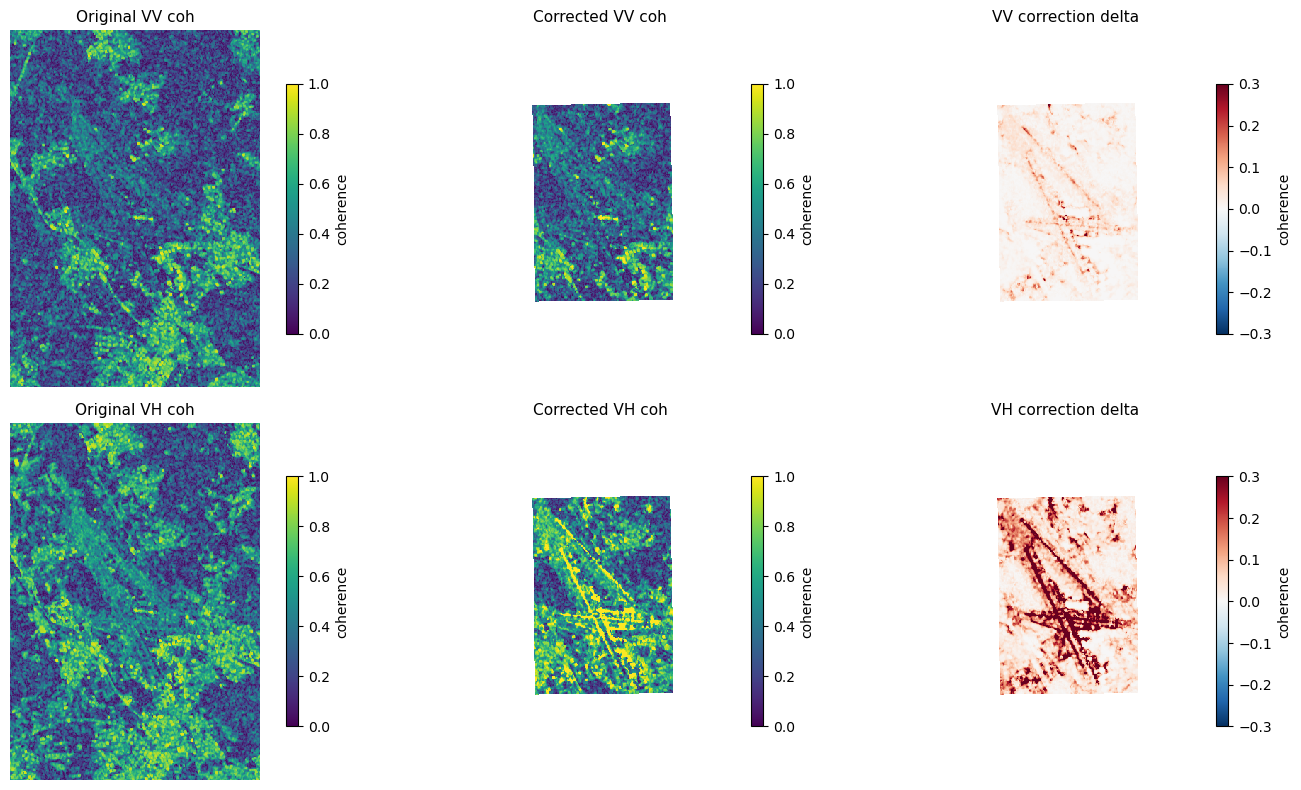

Saved spot-check to c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/docs/images/snr_correction


In [11]:
# Pick first successfully corrected event for visual comparison
sample_ids = report_df[report_df['before_ok'] & report_df['after_ok']]['match_id'].tolist()
if not sample_ids:
    print("No fully corrected events to show.")
else:
    sid = sample_ids[0]
    orig_path = f"{COH_DIR}/{sid}_coh_before.tif"
    corr_path = f"{COH_CORR_DIR}/{sid}_coh_before_snrcorr.tif"

    # Load original and corrected coherence for this event
    with rasterio.open(orig_path) as src:
        vv_idx, vh_idx = get_coh_bands(src)
        orig_vv = src.read(vv_idx + 1).astype(float); orig_vv[orig_vv <= 0] = np.nan
        orig_vh = src.read(vh_idx + 1).astype(float); orig_vh[orig_vh <= 0] = np.nan

    with rasterio.open(corr_path) as src:
        corr_vv = src.read(1).astype(float); corr_vv[corr_vv <= 0] = np.nan
        corr_vh = src.read(2).astype(float); corr_vh[corr_vh <= 0] = np.nan

    # Visualize original vs corrected coherence and the correction delta
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    panels = [
        (orig_vv, 'Original VV coh',  'viridis', (0, 1)),
        (corr_vv, 'Corrected VV coh', 'viridis', (0, 1)),
        (corr_vv - orig_vv, 'VV correction delta', 'RdBu_r', (-0.3, 0.3)),
        (orig_vh, 'Original VH coh',  'viridis', (0, 1)),
        (corr_vh, 'Corrected VH coh', 'viridis', (0, 1)),
        (corr_vh - orig_vh, 'VH correction delta', 'RdBu_r', (-0.3, 0.3)),
    ]
    for ax, (arr, title, cmap, (vmin, vmax)) in zip(axes.flat, panels):
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='none')
        ax.set_title(title, fontsize=11); ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.7, label='coherence')

    # plt.suptitle(f'match_id={sid}, coh_before: original vs SNR-corrected', y=1.01)
    plt.tight_layout()
    plt.savefig(f"{IMG_OUT_DIR}/spotcheck_coh_before_{sid}.png",
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved spot-check to {IMG_OUT_DIR}")


## 4. Diagnostic on SNR-corrected data
More detailed analysis of the differences between hte original and SNR-correcetd coherence values.

First a dataframe combining all necessary information is prepared

In [12]:
# Load AV grassland parcels
av_all = gpd.read_file(AV_GPKG, layer='Bodenbedeckung_BoFlaeche_Area')
av = av_all[av_all['Art_TXT'] == 'humusiert.Acker_Wiese_Weide'].copy().reset_index(drop=True)
av['parcel_area_m2'] = av.geometry.area
print(f"Grassland parcels: {len(av)}")

# Load event dates
tm = pd.read_csv(TM_CSV, parse_dates=['event_date'])
slc_raw = pd.read_csv(SLC_IDX_CSV)
events = slc_raw[['match_id','event_date_str']].merge(
    tm[['event_date_str','event_date']].drop_duplicates('event_date_str'),
    on='event_date_str', how='left'
)
events['event_date'] = pd.to_datetime(events['event_date'])
events = events.dropna(subset=['event_date']).set_index('match_id')

# Helper to assign season based on month
def assign_season(date):
    m = date.month
    if m in (4, 5):
        return 'early'
    if m in (6, 7):
        return 'peak'
    if m in (8, 9, 10):
        return 'late'
    return 'other'


SEASON_ORDER = ['early', 'peak', 'late', 'other']
SEASON_LABELS = {
    'early': 'Early (Apr-May)', 'peak': 'Peak (Jun-Jul)',
    'late': 'Late (Aug-Oct)',   'other': 'Other',
}

MOWED_FRAC_THRESHOLD = 0.30
MIN_COH_PIXELS = 2

Grassland parcels: 577


In [13]:
# Corrected TIFs: 2-band (VV=1, VH=2), band detection not needed
corr_before = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_CORR_DIR}/*_coh_before_snrcorr.tif")}
corr_after = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_CORR_DIR}/*_coh_after_snrcorr.tif")}
corr_ids = sorted(set(corr_before) & set(corr_after))

print(f"Corrected before TIFs: {len(corr_before)}")
print(f"Corrected after  TIFs: {len(corr_after)}")
print(f"Both pairs available:  {len(corr_ids)}")


Corrected before TIFs: 36
Corrected after  TIFs: 36
Both pairs available:  36


In [ ]:
# Helper functions to compute parcel-level metrics from corrected TIFs
def parcel_mean_coh_2band(src, geom, band_1idx):
    """Mean coherence for a parcel from a 2-band SNR-corrected TIF."""
    try:
        arr, _ = rio_mask(src, [geom], crop=True, filled=True, nodata=np.nan,
                          indexes=band_1idx, all_touched=False)
        arr = arr.astype(float)
        valid = arr[(np.isfinite(arr)) & (arr > 0.001)]
        return float(np.mean(valid)) if valid.size >= MIN_COH_PIXELS else np.nan
    except Exception:
        return np.nan

def parcel_gt_frac(gt_src, geom):
    try:
        arr, _ = rio_mask(gt_src, [geom], crop=True, filled=True, nodata=255,
                          indexes=1, all_touched=False)
        arr = arr.astype(np.uint8).ravel()
        valid = arr[arr != 255]
        return float(np.sum(valid == 1) / valid.size) if valid.size > 0 else np.nan
    except Exception:
        return np.nan

# Initialize list to hold parcel-event records
records_corr = []

# Process each event with corrected coherence and compute parcel-level metrics
for mid in corr_ids:
    if mid not in events.index:
        continue
    ev_date = events.loc[mid, 'event_date']
    season  = assign_season(ev_date)
    date_str = str(int(events.loc[mid, 'event_date_str']))

    bp = corr_before[mid]
    ap = corr_after[mid]
    mp = f"{MASKS_DIR}/mask_{date_str}.tif"

    if not os.path.exists(mp):
        continue
    
    # Open corrected coherence before/after and ground truth mask, compute parcel-level metrics
    with rasterio.open(bp) as src_b, rasterio.open(ap) as src_a,          rasterio.open(mp) as src_gt:

        coh_bbox = box(*src_b.bounds)
        av_sub   = av[av.intersects(coh_bbox)].copy()

        for _, p in av_sub.iterrows():
            geom = p.geometry

            gt_frac = parcel_gt_frac(src_gt, geom)
            if np.isnan(gt_frac):
                continue

            bef_vv = parcel_mean_coh_2band(src_b, geom, 1)
            aft_vv = parcel_mean_coh_2band(src_a, geom, 1)
            bef_vh = parcel_mean_coh_2band(src_b, geom, 2)
            aft_vh = parcel_mean_coh_2band(src_a, geom, 2)

            if np.isnan(bef_vv) or np.isnan(aft_vv):
                continue

            records_corr.append({
                'match_id':      mid,
                'event_date':    ev_date,
                'season':        season,
                'parcel_id':     p['OBJID'],
                'coh_before_vv': bef_vv, 'coh_after_vv': aft_vv,
                'coh_before_vh': bef_vh, 'coh_after_vh': aft_vh,
                'gt_frac':       gt_frac,
                'label':         1 if gt_frac >= MOWED_FRAC_THRESHOLD else 0,
            })

# Create DataFrame of corrected parcel-event records and summarize
df_corr = pd.DataFrame(records_corr)
print(f"Parcel-event records (corrected): {len(df_corr)}")
print(f"Mowed: {df_corr['label'].sum()}  Not-mowed: {(df_corr['label']==0).sum()}")
print("\nCount by season x label:")
print(df_corr.groupby(['season','label']).size().unstack(fill_value=0).reindex(SEASON_ORDER).dropna(how='all'))


Parcel-event records (corrected): 17178
Mowed: 316  Not-mowed: 16862

Count by season x label:
label        0      1
season               
early   3762.0   62.0
peak    9372.0  168.0
late    3728.0   86.0


### Diagnostic plots:  SNR-corrected coherence

Four diagnostic plots comparing SNR-corrected coherence distributions between mowed and not-mowed parcels, split by season. Plots A and B show histograms of post-mowing coherence for VH and VV polarization respectively, with reference lines from Tamm et al. for expected coherence thresholds. Plots C and D are scatter plots of before vs. after coherence (VH and VV), where parcels below the 1:1 diagonal experienced a coherence drop. Together these visualize whether mowing produces a detectable coherence signal and how it varies across polarizations and seasons.

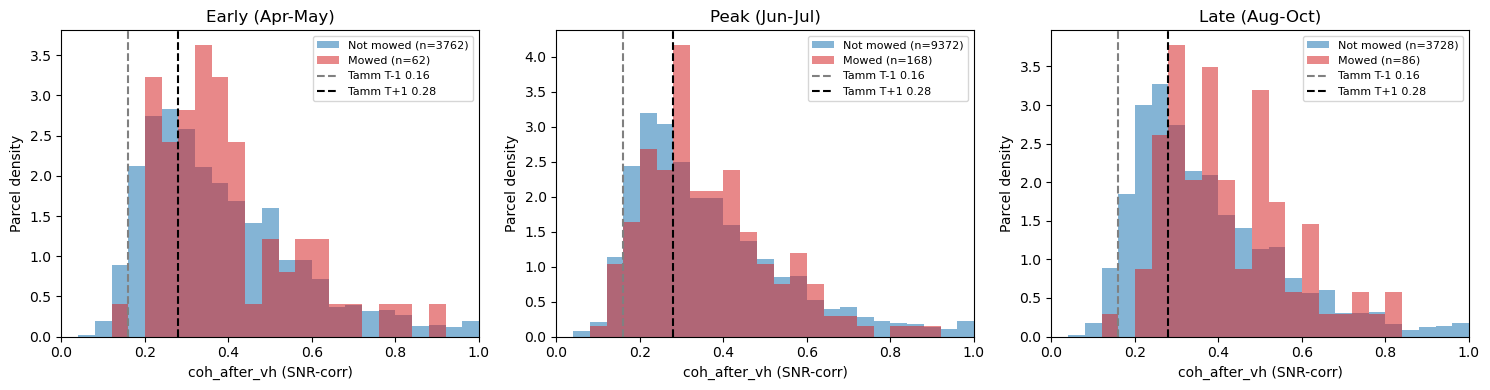

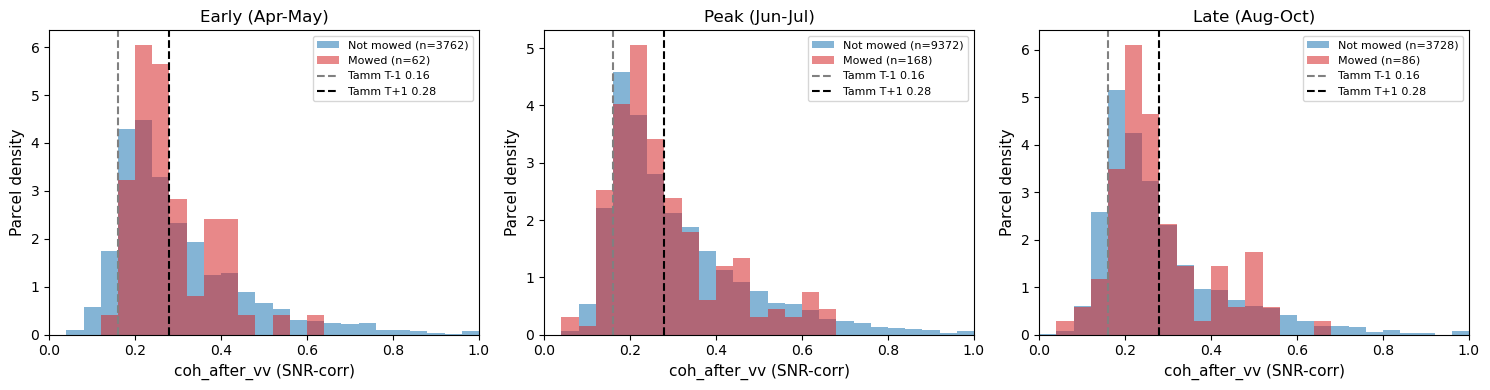

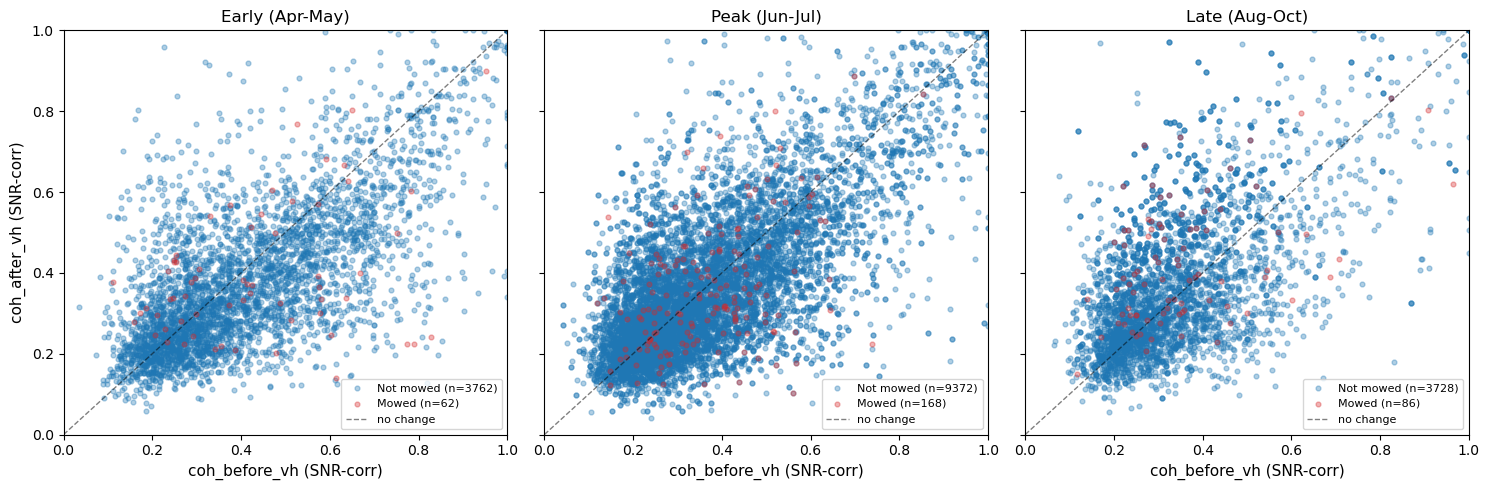

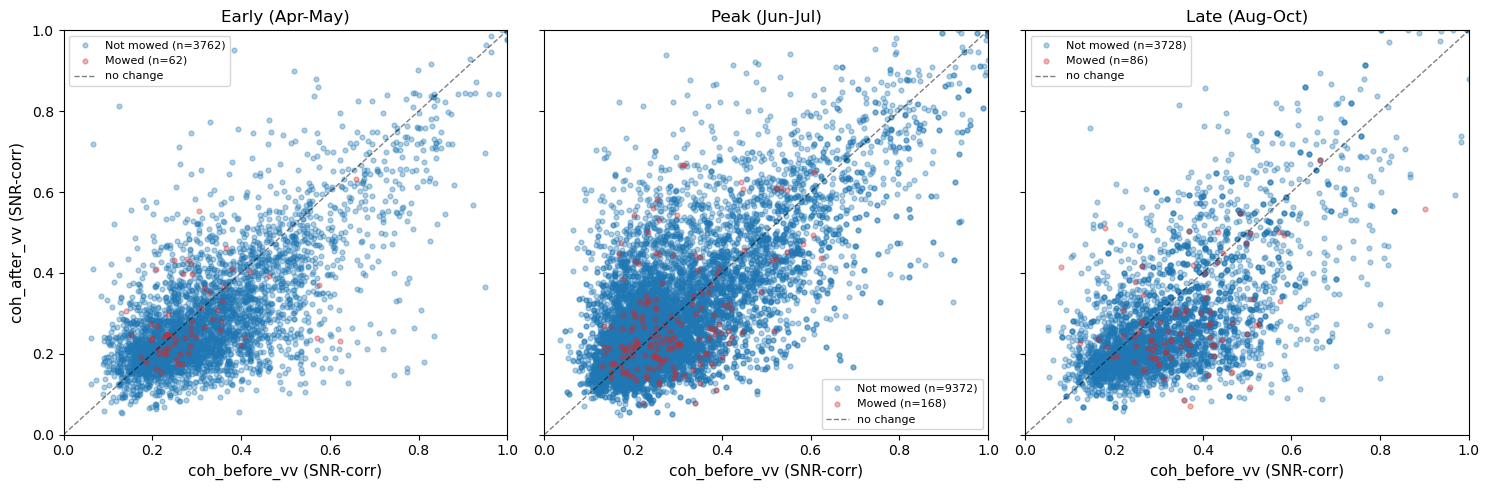

All plots saved to c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/docs/images/snr_correction


In [23]:
seasons_plot = [s for s in SEASON_ORDER
                if s in df_corr['season'].unique() and s != 'other']
n_seasons    = len(seasons_plot)
colors       = {1: '#d62728', 0: '#1f77b4'}
labels_map   = {1: 'Mowed', 0: 'Not mowed'}

# Plot A: coh_vh after mowing, by season and label
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 4))
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_after_vh'].dropna()
        if vals.empty: continue
        ax.hist(vals, bins=25, range=(0,1), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})", density=True)
    ax.axvline(0.16, color='grey',  ls='--', lw=1.5, label='Tamm T-1 0.16')
    ax.axvline(0.28, color='black', ls='--', lw=1.5, label='Tamm T+1 0.28')
    ax.set_title(SEASON_LABELS[season])
    ax.set_xlabel('coh_after_vh (SNR-corr)')
    ax.set_ylabel('Parcel density')
    ax.legend(fontsize=8)
    ax.set_xlim(0,1)
# plt.suptitle('Plot A (SNR-corrected): Post-mowing VH coherence by season', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMG_OUT_DIR}/plot_A_coh_vh_after.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot A: coh_vv after mowing, by season and label
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 4))
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_after_vv'].dropna()
        if vals.empty: continue
        ax.hist(vals, bins=25, range=(0,1), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})", density=True)
    ax.axvline(0.16, color='grey',  ls='--', lw=1.5, label='Tamm T-1 0.16')
    ax.axvline(0.28, color='black', ls='--', lw=1.5, label='Tamm T+1 0.28')
    ax.set_title(SEASON_LABELS[season])
    ax.set_xlabel('coh_after_vv (SNR-corr)', fontsize=11)
    ax.set_ylabel('Parcel density', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlim(0,1)
# plt.suptitle('Plot A (SNR-corrected): Post-mowing VV coherence by season', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMG_OUT_DIR}/plot_B_coh_vv_after.png", dpi=300, bbox_inches='tight')
plt.show()



# Plot C: scatter before vs after VH
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 5), sharey=True, sharex=True)
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        s = sub[sub['label'] == lbl]
        if s.empty: continue
        ax.scatter(s['coh_before_vh'], s['coh_after_vh'],
                   c=colors[lbl], alpha=0.35, s=12,
                   label=f"{labels_map[lbl]} (n={len(s)})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='no change')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('coh_before_vh (SNR-corr)', fontsize=11)
    ax.set_title(SEASON_LABELS[season], fontsize=12)
    ax.legend(fontsize=8)
axes[0].set_ylabel('coh_after_vh (SNR-corr)', fontsize=11)
#plt.suptitle('Plot C (SNR-corrected): VH coh before vs after', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMG_OUT_DIR}/plot_C_scatter_vh.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot D: scatter before vs after VV
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 5), sharey=True, sharex=True)
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        s = sub[sub['label'] == lbl]
        if s.empty: continue
        ax.scatter(s['coh_before_vv'], s['coh_after_vv'],
                   c=colors[lbl], alpha=0.35, s=12,
                   label=f"{labels_map[lbl]} (n={len(s)})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='no change')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('coh_before_vv (SNR-corr)', fontsize=11)
    ax.set_title(SEASON_LABELS[season], fontsize=12)
    ax.legend(fontsize=8)
axes[0].set_ylabel('coh_after_vv (SNR-corr)', fontsize=11)
#plt.suptitle('Plot D (SNR-corrected): VV coh before vs after', y=1.01)
plt.tight_layout()
plt.savefig(f"{IMG_OUT_DIR}/plot_D_scatter_vv.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"All plots saved to {IMG_OUT_DIR}")

### Comparison table: before vs after SNR correction
Analyse if SNR correction improves seperability between mowed and not mowed parcels. Both are compared side-by-side using Cohen's d (effect size) and Mann-Whitney U test on post-mowing coherence, broken down into season and polarization.

In [ ]:
# Rebuild original parcel stats for the same set of events
def get_coh_bands_orig(src):
    coh = []
    for b in range(1, src.count + 1):
        win = rasterio.windows.Window(0, 0, min(200, src.width), min(200, src.height))
        arr = src.read(b, window=win).astype(float)
        valid = arr[(arr > 0.001) & np.isfinite(arr)]
        if valid.size > 50 and valid.max() <= 1.0:
            coh.append(b - 1)
    return (coh[0] if len(coh) > 0 else None,
            coh[1] if len(coh) > 1 else None)

# Helper to compute mean coherence for a parcel from original TIFs
def parcel_mean_coh_orig(src, geom, band_0idx):
    try:
        arr, _ = rio_mask(src, [geom], crop=True, filled=True, nodata=np.nan,
                          indexes=band_0idx+1, all_touched=False)
        arr = arr.astype(float)
        valid = arr[(np.isfinite(arr)) & (arr > 0.001)]
        return float(np.mean(valid)) if valid.size >= MIN_COH_PIXELS else np.nan
    except Exception:
        return np.nan

# Initialize list to hold original parcel-event records
records_orig = []

# Process each event with original coherence and compute parcel-level metrics
for mid in corr_ids:
    if mid not in events.index: continue
    ev_date = events.loc[mid, 'event_date']
    season  = assign_season(ev_date)
    date_str = str(int(events.loc[mid, 'event_date_str']))

    bp = f"{COH_DIR}/{mid}_coh_before.tif"
    ap = f"{COH_DIR}/{mid}_coh_after.tif"
    mp = f"{MASKS_DIR}/mask_{date_str}.tif"
    if not (os.path.exists(bp) and os.path.exists(ap) and os.path.exists(mp)):
        continue
    
    # Open original coherence before/after and ground truth mask, compute parcel-level metrics
    with rasterio.open(bp) as src_b, rasterio.open(ap) as src_a, rasterio.open(mp) as src_gt:
        vv_b, vh_b = get_coh_bands_orig(src_b)
        vv_a, vh_a = get_coh_bands_orig(src_a)
        if vv_b is None or vv_a is None: continue

        coh_bbox = box(*src_b.bounds)
        av_sub   = av[av.intersects(coh_bbox)].copy()

        for _, p in av_sub.iterrows():
            geom    = p.geometry
            gt_frac = parcel_gt_frac(src_gt, geom)
            if np.isnan(gt_frac): continue

            bef_vv = parcel_mean_coh_orig(src_b, geom, vv_b)
            aft_vv = parcel_mean_coh_orig(src_a, geom, vv_a)
            bef_vh = parcel_mean_coh_orig(src_b, geom, vh_b) if vh_b is not None else np.nan
            aft_vh = parcel_mean_coh_orig(src_a, geom, vh_a) if vh_a is not None else np.nan
            if np.isnan(bef_vv) or np.isnan(aft_vv): continue

            records_orig.append({
                'match_id': mid, 'event_date': ev_date, 'season': season,
                'parcel_id': p['OBJID'],
                'coh_before_vv': bef_vv, 'coh_after_vv': aft_vv,
                'coh_before_vh': bef_vh, 'coh_after_vh': aft_vh,
                'gt_frac': gt_frac,
                'label': 1 if gt_frac >= MOWED_FRAC_THRESHOLD else 0,
            })

# Create DataFrame of original parcel-event records and summarize
df_orig = pd.DataFrame(records_orig)
print(f"Original parcel records (same event set): {len(df_orig)}")


Original parcel records (same event set): 17270


In [22]:
def cohens_d(a, b):
    a, b = np.array(a)[~np.isnan(np.array(a))], np.array(b)[~np.isnan(np.array(b))]
    if len(a) < 2 or len(b) < 2: return np.nan
    pooled = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2)
                     / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def mw_p(a, b):
    a = np.array(a)[~np.isnan(np.array(a))]
    b = np.array(b)[~np.isnan(np.array(b))]
    if len(a) < 2 or len(b) < 2: return np.nan
    _, p = stats.mannwhitneyu(a, b, alternative='greater')
    return p

rows = []

for season in ['early', 'peak', 'late']:
    for pol, before_col, after_col in [
        ('VV', 'coh_before_vv', 'coh_after_vv'),
        ('VH', 'coh_before_vh', 'coh_after_vh'),
    ]:
        for version, df_v in [('Original', df_orig), ('SNR-corrected', df_corr)]:
            sub = df_v[df_v['season'] == season]
            mow = sub[sub['label'] == 1]
            not_mow = sub[sub['label'] == 0]

            bef_mow = mow[before_col].dropna()
            aft_mow = mow[after_col].dropna()
            bef_nm = not_mow[before_col].dropna()
            aft_nm = not_mow[after_col].dropna()

            rows.append({
                'Season': SEASON_LABELS.get(season, season),
                'Pol': pol,
                'Version': version,
                'n_mowed': len(mow),
                'n_not_mowed': len(not_mow),
                'mean_before_mowed': f"{bef_mow.mean():.3f}" if len(bef_mow) > 0 else 'N/A',
                'mean_after_mowed': f"{aft_mow.mean():.3f}" if len(aft_mow) > 0 else 'N/A',
                'mean_before_not_mowed': f"{bef_nm.mean():.3f}" if len(bef_nm) > 0 else 'N/A',
                'mean_after_not_mowed': f"{aft_nm.mean():.3f}" if len(aft_nm) > 0 else 'N/A',
                "Cohen's d (after)": f"{cohens_d(aft_mow, aft_nm):.3f}",
                'MW p (after, mow>not)': f"{mw_p(aft_mow, aft_nm):.4f}",
            })

cmp_df = pd.DataFrame(rows)
print("=== Seasonal comparison: Original vs SNR-corrected coherence ===")
with pd.option_context('display.max_columns', None, 'display.width', 250):
    print(cmp_df.to_string(index=False))

cmp_df.to_csv(f"../docs/tables/seasonal_coherence_comparison.csv", index=False)

=== Seasonal comparison: Original vs SNR-corrected coherence ===
         Season Pol       Version  n_mowed  n_not_mowed mean_before_mowed mean_after_mowed mean_before_not_mowed mean_after_not_mowed Cohen's d (after) MW p (after, mow>not)
Early (Apr-May)  VV      Original       62         3762             0.271            0.264                 0.320                0.282            -0.126                0.4819
Early (Apr-May)  VV SNR-corrected       62         3762             0.295            0.285                 0.339                0.299            -0.092                0.3097
Early (Apr-May)  VH      Original       62         3762             0.334            0.311                 0.343                0.316            -0.034                0.5311
Early (Apr-May)  VH SNR-corrected       62         3762             0.433            0.394                 0.415                0.381             0.070                0.1441
 Peak (Jun-Jul)  VV      Original      168         9440          